In [1]:
import pandas as pd
import numpy as np
import json
import ast

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from shapely.geometry import Point
import kaleido

In [3]:
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False 

In [4]:
analyse_data=pd.read_csv('analyse_data.csv')
candidates_gdf=gpd.read_file('candidates_gdf.geojson')
geometry_target=gpd.read_parquet('geometry_target.parquet')
geometry_competitor=gpd.read_parquet('geometry_competitor.parquet')
poi_geo_data=gpd.read_parquet('poi_geo_data.parquet')

In [5]:
malls_buffer=gpd.read_file('malls_buffer.shp')
offices_buffer=gpd.read_file('offices_buffer.shp')
subway_buffer=gpd.read_file('subway_buffer.shp')

# 1.品牌布局基础盘量化对比

## 1.1分行政区统计门店数量与密度

In [6]:
adname_target=analyse_data[analyse_data['name'].str.contains('星巴克', na=False)]['adname']
adname_competitor=analyse_data[analyse_data['name'].str.contains('瑞幸咖啡|库迪咖啡', na=False)]['adname']

In [7]:
geometry_target['adname']=adname_target.values
geometry_competitor['adname']=adname_competitor.values

In [8]:
geometry_target['brand']='星巴克'
geometry_competitor['brand']='竞品(瑞幸+库迪)'

In [9]:
#分行政区统计门店数量与密度
all_store_df=pd.concat([geometry_target[["brand", "adname", "rating", "cost", "overlap_ratio", "comp_overlap_ratio"]],
                       geometry_competitor[["brand", "adname", "rating", "cost"]]])

In [10]:
# 分行政区+品牌统计核心指标
layout_compare=all_store_df.groupby(['adname','brand']).agg(
    门店数量=("brand", "count"),
    平均门店评分=("rating", "mean"),
    平均人均消费=("cost", "mean")
).unstack().fillna(0)

In [11]:
# 计算市场占比
layout_compare['星巴克市场占比']=(layout_compare[('门店数量','星巴克')]/(layout_compare[('门店数量','星巴克')]+layout_compare[('门店数量','竞品(瑞幸+库迪)')])*100).round(2)
layout_compare['竞品市场占比']=(layout_compare[('门店数量','竞品(瑞幸+库迪)')]/(layout_compare[('门店数量','星巴克')]+layout_compare[('门店数量','竞品(瑞幸+库迪)')])*100).round(2)

In [12]:
layout_compare

门店数量              平均门店评分               平均人均消费            星巴克市场占比 竞品市场占比
brand   星巴克 竞品(瑞幸+库迪)       星巴克 竞品(瑞幸+库迪)        星巴克  竞品(瑞幸+库迪)               
adname                                                                        
天河区      14        52  4.485714  4.298077  35.428571  14.423077   21.21  78.79
海珠区       1         1  4.400000  4.400000  35.000000  13.000000   50.00  50.00
荔湾区      10        26  4.450000  4.261538  36.400000  13.269231   27.78  72.22
越秀区      22        38  4.481818  4.276316  34.181818  14.657895   36.67  63.33

数据基础说明：本表为广州中心城区 4 个行政区，目标品牌星巴克与核心竞品（瑞幸咖啡、库迪咖啡）的布局与经营表现量化对比，覆盖门店规模、用户口碑、消费定位、市场份额 4 个核心维度，为后续区域布局策略提供基础判断。

## 1.2核心业务洞察

（1）市场格局：竞品全域渗透率更高，星巴克仍保持品牌优势

4 个行政区内，竞品的门店数量均超过星巴克，整体市场占比超 70%，已完成全域广泛布局；但星巴克在所有区域的门店评分、人均消费均显著高于竞品，品牌溢价与用户口碑优势明显，具备差异化竞争的核心基础。

（2）优势区域：越秀区是星巴克的核心基本盘

越秀区星巴克门店数量最多（22 家），市场占比达 36.67%，为 4 个区域最高，同时保持了 4.48 的高评分，是品牌布局最成熟、市场话语权最强的区域，后续可作为标杆区域提炼可复制的选址逻辑。

（3）机会区域：海珠区是核心空白市场，荔湾区存在差异化拓展机会

海珠区双方仅各布局 1 家门店，咖啡市场尚未充分开发，是零内卷的高潜力空白区域；荔湾区竞品渗透率达 72.22%，但星巴克的人均消费、评分仍大幅领先竞品，可依托品牌优势，在竞品未覆盖的优质点位做差异化布局。

（4）竞争警示：天河区是高竞争红海区域

天河区竞品门店数量达 52 家，市场占比近 80%，是竞争最激烈的区域；但星巴克仍保持了全区域最高的人均消费与评分，说明品牌在核心办公商圈的高价值客群中仍有强吸引力，后续布局需避开竞品密集的红海点位，聚焦高价值办公客群的空白区域。



# 2.门店竞争环境与经营表现关联分析

## 2.1内部内卷和外部竞争的整体情况

In [13]:
print("=== 星巴克门店竞争环境整体统计 ===")
competition_stats = geometry_target[["overlap_ratio", "comp_overlap_ratio", "rating", "cost"]].describe().round(3)
print(competition_stats)

=== 星巴克门店竞争环境整体统计 ===
       overlap_ratio  comp_overlap_ratio  rating    cost
count         47.000              47.000  47.000  47.000
mean           3.660               7.401   4.474  35.043
std            3.060               3.787   0.129   4.667
min            0.000               0.470   4.200  28.000
25%            1.203               4.432   4.400  31.000
50%            2.863               6.907   4.500  34.000
75%            5.913              10.719   4.600  38.000
max            9.422              13.440   4.700  45.000


星巴克在广州 4 区的现有布局几乎没有同品牌内卷：内部重叠度最高仅 9.42%，75% 的门店内部重叠度低于 6%，说明现有门店的布局非常克制，没有自我分流的问题，选址逻辑成熟度很高；同时和竞品的重叠度最高仅 13.44%，和瑞幸、库迪的布局错位明显，没有正面硬刚的红海竞争。

## 2.2双维度竞争分级

本次竞争分级没有采用通用的固定阈值，而是基于星巴克在广州中心城区 47 家现有门店的实际布局数据，以指标中位数作为分界标准。这种方式更贴合广州本地的市场格局和品牌现有选址逻辑，避免了通用阈值在不同城市、不同市场的水土不服，分级结果更具本地参考价值。

1.内部内卷

低水平阈值：≤ 中位数2.86

高水平阈值：> 中位数2.86

2.外部竞争

低水平阈值：≤ 中位数6.91

高水平阈值：> 中位数6.91

In [14]:
def get_competition_level(row):
    inner_low=row['overlap_ratio']<2.86
    outer_low=row['comp_overlap_ratio']<6.91
    if inner_low and outer_low:
        return '1.黄金区域（低内卷+低竞争）'
    elif inner_low and not outer_low:
        return '2.差异化竞争区（低内卷+高竞争）'
    elif not inner_low and outer_low:
        return '3.填补空白区（高内卷+低竞争）'
    else:
        return '4.红海区域（高内卷+高竞争）'
geometry_target['comp_classification']=geometry_target.apply(get_competition_level,axis=1)

## 2.3不同竞争环境下的经营表现对比

In [15]:
performance_compare = geometry_target.groupby("comp_classification").agg(
    平均门店评分=("rating", "mean"),
    平均人均消费=("cost", "mean")
).round(2).reset_index()

In [16]:
performance_compare

,comp_classification,平均门店评分,平均人均消费
0,1.黄金区域（低内卷+低竞争）,4.44,35.65
1,2.差异化竞争区（低内卷+高竞争）,4.53,35.33
2,3.填补空白区（高内卷+低竞争）,4.45,38.50
3,4.红海区域（高内卷+高竞争）,4.50,33.70


In [17]:
plot_perf_df = performance_compare.melt(
    id_vars="comp_classification",
    value_vars=["平均门店评分", "平均人均消费"],
    var_name="经营指标",
    value_name="数值"
)

In [18]:
plot_perf_df

,comp_classification,经营指标,数值
0,1.黄金区域（低内卷+低竞争）,平均门店评分,4.44
1,2.差异化竞争区（低内卷+高竞争）,平均门店评分,4.53
2,3.填补空白区（高内卷+低竞争）,平均门店评分,4.45
3,4.红海区域（高内卷+高竞争）,平均门店评分,4.50
4,1.黄金区域（低内卷+低竞争）,平均人均消费,35.65
5,2.差异化竞争区（低内卷+高竞争）,平均人均消费,35.33
6,3.填补空白区（高内卷+低竞争）,平均人均消费,38.50
7,4.红海区域（高内卷+高竞争）,平均人均消费,33.70


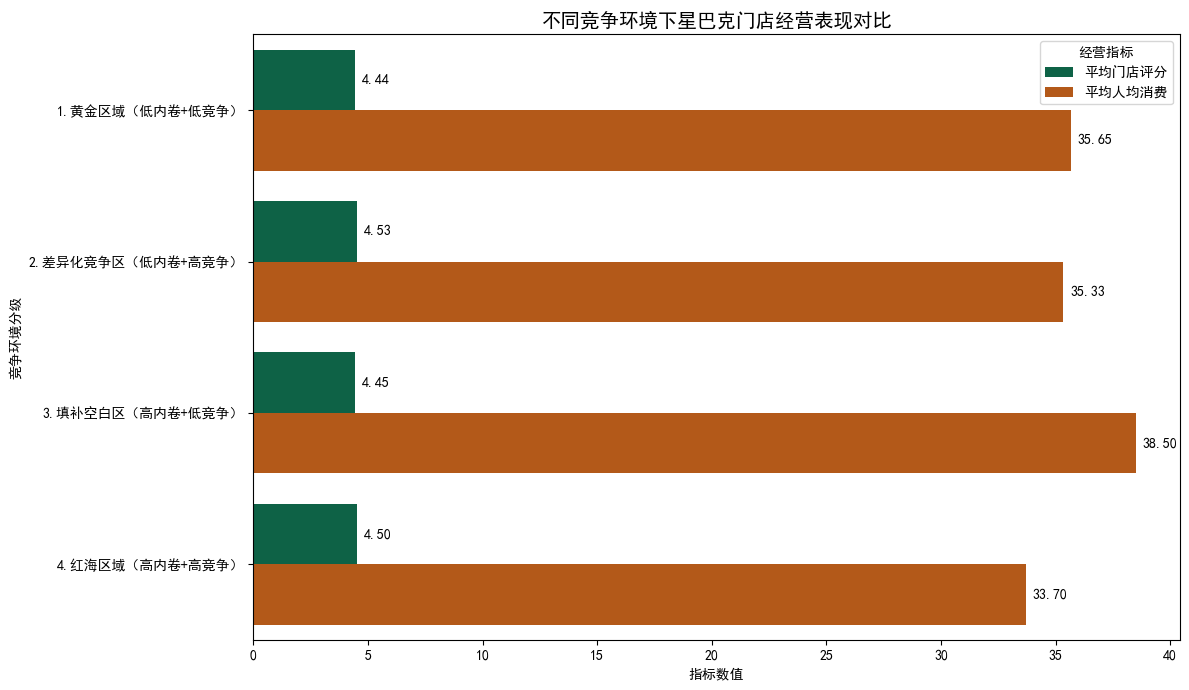

In [19]:
fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(
    data=plot_perf_df,
    y="comp_classification",
    x="数值",
    hue="经营指标",
    palette=["#00704A", "#CC5500"],  
    ax=ax
)
for container in ax.containers:
    ax.bar_label(container, padding=5, fmt="%.2f")
ax.set_ylabel("竞争环境分级")
ax.set_xlabel("指标数值")
ax.set_title("不同竞争环境下星巴克门店经营表现对比", fontweight="bold", fontsize=14)
ax.legend(title="经营指标")
plt.tight_layout()
plt.show()
fig.savefig("竞争环境经营表现对比图.png", dpi=300, bbox_inches="tight")

## 2.4核心数据洞察

本次基于星巴克广州 47 家现有门店，通过「内部内卷 - 外部竞争」双维度矩阵做了 4 类竞争环境分级，不同环境下的门店经营表现呈现 3 个核心特征：

1.品牌口碑极强的抗竞争稳定性：4 类竞争环境下，门店平均评分差异极小（最大差值仅 0.09 分），均稳定在 4.44-4.53 分区间。说明星巴克的标准化运营、产品与服务品质，几乎不受外部竞品竞争、同品牌内卷的影响，用户口碑具备极强的品牌护城河，这是品牌差异化布局的核心基础。

2.竞争环境直接影响单店消费溢价：人均消费呈现显著的梯度差异，核心规律为「竞争越弱，人均消费越高」:

填补空白区（高内卷 + 低竞争）人均消费断层最高，达 38.50 元，比最低的红海区域高出 14.2%；

红海区域（高内卷 + 高竞争）人均消费最低，仅 33.70 元，充分验证了密集的竞品竞争会引发价格分流，拉低单店营收效率。

3.错位布局可实现口碑与客单价的双稳定：差异化竞争区（低内卷 + 高竞争）在竞品密集的环境下，仍保持了 4.53 分的全区域最高评分，同时人均消费稳定在 35.33 元，说明星巴克的品牌力可支撑其在竞品密集区域实现错位竞争，不会被低价竞品冲击核心客群。

# 3.单店覆盖效率对比

In [20]:
#计算现有目标品牌门店指定半径内购物中心的数量
geometry_target['mall_count']=geometry_target.geometry.apply(lambda p: malls_buffer.contains(p).sum())

In [21]:
#计算现有目标品牌门店指定半径内办公楼的数量
geometry_target['office_count']=geometry_target.geometry.apply(lambda p: offices_buffer.contains(p).sum())

In [22]:
#计算现有目标品牌门店指定半径内地铁出入口的数量
geometry_target['subway_count']=geometry_target.geometry.apply(lambda p: subway_buffer.contains(p).sum())

In [23]:
#计算现有竞品门店指定半径内购物中心的数量
geometry_competitor['mall_count']=geometry_competitor.geometry.apply(lambda p: malls_buffer.contains(p).sum())

In [24]:
#计算现有竞品门店指定半径内办公楼的数量
geometry_competitor['office_count']=geometry_competitor.geometry.apply(lambda p: offices_buffer.contains(p).sum())

In [25]:
#计算现有竞品门店指定半径内地铁出入口的数量
geometry_competitor['subway_count']=geometry_competitor.geometry.apply(lambda p: subway_buffer.contains(p).sum())

In [26]:
plot_store_df=layout_compare[[("门店数量", "星巴克"), ("门店数量", "竞品(瑞幸+库迪)")]].reset_index()

In [27]:
plot_store_df.columns = ["adname", "星巴克门店数", "竞品(瑞幸+库迪)门店数"]

In [28]:
x = np.arange(len(plot_store_df["adname"]))  
width = 0.35

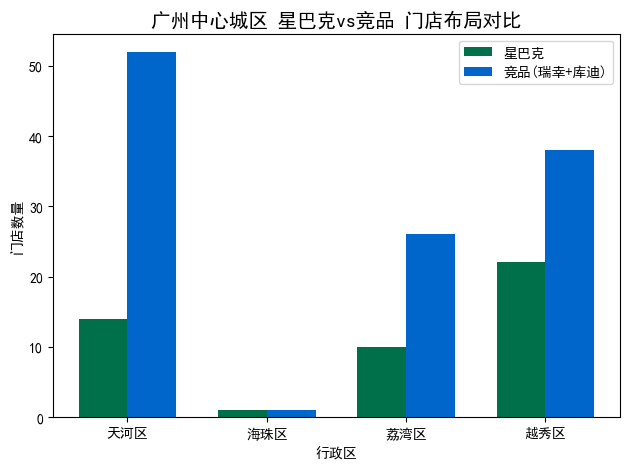

In [29]:
fig, ax = plt.subplots()
rects1 = ax.bar(x - width/2, plot_store_df["星巴克门店数"], width, label="星巴克", color="#00704A")
rects2 = ax.bar(x + width/2, plot_store_df["竞品(瑞幸+库迪)门店数"], width, label="竞品(瑞幸+库迪)", color="#0066CC")
ax.set_xlabel("行政区")
ax.set_ylabel("门店数量")
ax.set_title("广州中心城区 星巴克vs竞品 门店布局对比", fontweight="bold", fontsize=14)
ax.set_xticks(x, plot_store_df["adname"])
ax.legend()
plt.tight_layout() 
plt.show()
fig.savefig("门店布局对比图.png", dpi=300, bbox_inches="tight")

广州 4 个中心城区星巴克和核心竞品的门店布局对比，可以看到竞品在所有行政区的门店数量都远超星巴克，其中天河区竞品门店数达到 52 家，是星巴克的 3.7 倍，是竞争最激烈的红海区域；而海珠区双方仅各 1 家门店，是尚未充分开发的空白市场，这也是星巴克后续开店策略的核心机会点。

**文件保存：**

In [30]:
#geometry_target.to_parquet('geometry_target.parquet')
#geometry_competitor.to_parquet('geometry_competitor.parquet')